# Automation or Rising Wealth?
### A within-dataset horse race between technological push and demand pull in the growth of US low-skill service employment, 1980–2005

**Python for Economists — Track B (corpus analysis) — AY 2025/2026**
**Group 17** · Olimpia Benelli · Carlotta Cosio · Tommaso Cotoloni · Matteo Tugu

---

**Research question.** Between 1980 and 2005 US low-skill *service* employment among noncollege workers grew by more than 50%, while routine middle-skill jobs collapsed — the U-shaped polarization of the labour market. Two mechanisms have been proposed, and the literature tests them *separately*:

* **Story A — Technological push** (Autor & Dorn, 2013). Automation of routine tasks displaces noncollege workers into manual, hard-to-automate service jobs. *Prediction:* commuting zones (CZs) more specialised in routine tasks in 1980 see larger subsequent service-employment growth. **Key measure:** routine employment share `RSH`.
* **Story B — Demand pull** (Moretti, 2010). Rising local high incomes raise demand for in-person services (a local multiplier). *Prediction:* CZs with faster growth in top/college wages see larger service-employment growth. **Key measure:** local top-wage growth.

This notebook puts both mechanisms in the **same** specification on the **same** data and lets the data choose.

**What it delivers (Track B):** (1) a *descriptive* output — the polarization fact and the location of routine jobs; and (2) an *analytical* output — a weighted-OLS horse race plus an instrumented (2SLS) estimate, with robust standard errors.


## 0 · Setup and reproducibility

All dependencies are listed in `requirements.txt`. The notebook runs top-to-bottom from a clean environment, uses no hard-coded absolute paths (it searches a few sensible locations for the three `.dta` files), and saves every figure and table to an `outputs/` folder.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.iv import IV2SLS

# consistent palette (matches the written proposal)
NAVY, GOLD, RED, GREY = "#1F3864", "#B8860B", "#A23B3B", "#7A7A7A"
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.titleweight": "bold"})

OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
print("Setup complete. Outputs will be saved to:", OUT.resolve())

Setup complete. Outputs will be saved to: /home/claude/nbrun/outputs


In [2]:
# ---- robust file loader: no hard-coded absolute paths ----
FILES = {
    "panel": "workfile2012.dta",            # CZ panel (main file)
    "rti":   "RTI-bypctile-1980.dta",       # routine share by skill percentile
    "wages": "dwg-byperc-1980-2005-czall.dta",  # wage growth by percentile
}
SEARCH = [Path("."), Path("data"), Path("/mnt/user-data/uploads"), Path.home()]

def find(fname):
    """Return the first existing path for `fname`, else raise a clear error."""
    for d in SEARCH:
        if (d / fname).exists():
            return d / fname
    raise FileNotFoundError(
        f"Could not find '{fname}'. Place the three .dta files next to this "
        f"notebook or in a ./data folder. Searched: {[str(s) for s in SEARCH]}")

def load(key):
    df, _ = pyreadstat.read_dta(str(find(FILES[key])))
    return df

panel = load("panel")
rti   = load("rti")
wages = load("wages")
print(f"panel {panel.shape} | rti {rti.shape} | wages {wages.shape}")

panel (3610, 111) | rti (100, 5) | wages (100, 20)


## 1 · The corpus

**Source & provenance.** The official replication package of **Autor & Dorn (2013)**, *“The Growth of Low-Skill Service Jobs and the Polarization of the US Labor Market”*, *American Economic Review* 103(5): 1553–1597. Deposited in the AEA Data and Code Repository / openICPSR, **project 112652** (DOI `10.3886/E112652V1`). Public, peer-reviewed and fully documented.

**Unit of observation.** A US **Commuting Zone** (Tolbert & Sizer, 1996) — a local labour market. The panel covers **722 CZs** spanning the entire mainland US (metropolitan and rural), observed at the Census years **1950, 1970, 1980, 1990, 2000** and the **2005 ACS**. The analysis window is 1980–2005, organised as three stacked decadal differences.

**Three files, three roles.**

| File | Unit | Role |
|---|---|---|
| `workfile2012.dta` | CZ × census year | main panel: routine share, service-employment change, wages, controls, the 1950 instrument |
| `RTI-bypctile-1980.dta` | 1980 skill percentile | routine occupation share along the skill distribution |
| `dwg-byperc-1980-2005-czall.dta` | 1980 skill percentile | observed vs counterfactual wage growth by percentile |


In [3]:
# helper: population-weighted mean
def wmean(x, w):
    x, w = np.asarray(x, float), np.asarray(w, float)
    m = ~(np.isnan(x) | np.isnan(w))
    return np.average(x[m], weights=w[m])

d80 = panel[panel.yr == 1980]
rsh_mean = wmean(d80.l_sh_routine33a, d80.timepwt48)

def wq(x, w, q):  # population-weighted quantile
    x, w = np.asarray(x, float), np.asarray(w, float)
    s = np.argsort(x); x, w = x[s], w[s]
    cw = np.cumsum(w) / w.sum()
    return float(np.interp(q, cw, x))

p20, p80 = wq(d80.l_sh_routine33a, d80.timepwt48, .20), wq(d80.l_sh_routine33a, d80.timepwt48, .80)

print(f"Commuting zones      : {panel.czone.nunique()}")
print(f"Census years         : {sorted(panel.yr.unique())}")
print(f"Panel rows           : {len(panel)}  (722 CZs x 5 years)")
print(f"Routine share RSH_1980: pop-weighted mean = {rsh_mean:.3f}")
print(f"                        P20 = {p20:.3f}, P80 = {p80:.3f}, 80/20 range = {p80-p20:.3f}")

Commuting zones      : 722
Census years         : [np.int64(1950), np.int64(1970), np.int64(1980), np.int64(1990), np.int64(2000)]
Panel rows           : 3610  (722 CZs x 5 years)
Routine share RSH_1980: pop-weighted mean = 0.331
                        P20 = 0.294, P80 = 0.365, 80/20 range = 0.072


## 2 · Descriptive output — wage polarization and where routine jobs sit

The first figure establishes the phenomenon and points at its task-based explanation.

* **Panel A** plots the smoothed change in real log hourly wages by 1980 skill percentile, 1980–2005 (the U-shape), together with a **counterfactual** in which service-occupation wage growth is set to zero. The gap at the left tail shows that the upward twist of the *lower* tail is driven by service occupations.
* **Panel B** plots the routine occupation share along the same skill axis. Routine work peaks in the **middle** of the distribution — exactly where wage growth is weakest. (The raw per-percentile series is noisy, so we apply a centered 9-point moving average, as the original figure smooths the series.)


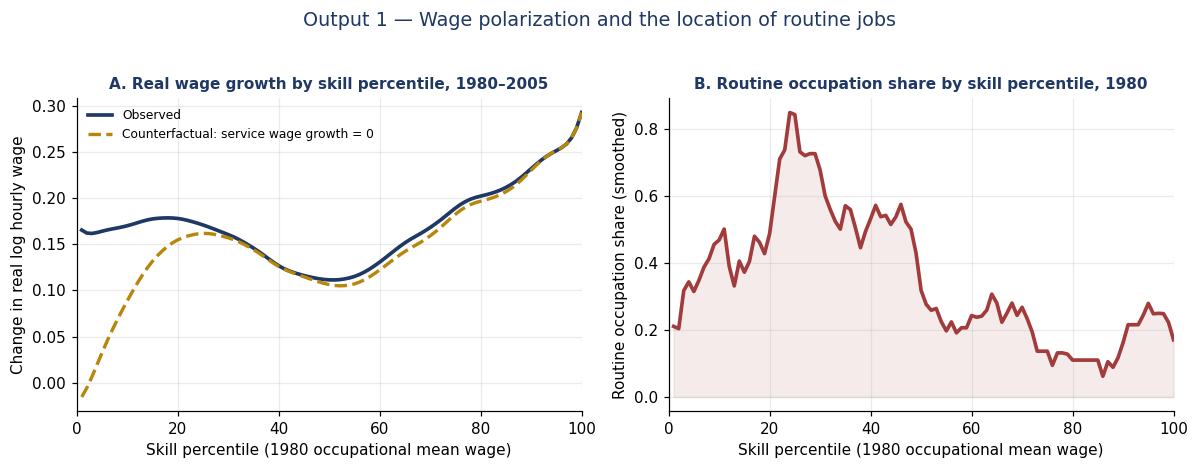

Saved outputs/output1_polarization.png


In [4]:
# --- Panel A data: observed vs counterfactual wage growth by percentile ---
wv = wages.sort_values("pctile")

# --- Panel B data: routine share by percentile (smoothed) ---
rt = rti.sort_values("pctile").reset_index(drop=True)
rt["smooth"] = rt["perc_R33a"].rolling(9, center=True, min_periods=1).mean()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
ax[0].plot(wv.pctile, wv.czall_pdperc8005, color=NAVY, lw=2.4, label="Observed")
ax[0].plot(wv.pctile, wv.czall_pdcntr8005, color=GOLD, lw=2.2, ls="--",
           label="Counterfactual: service wage growth = 0")
ax[0].set_title("A. Real wage growth by skill percentile, 1980–2005", color=NAVY, fontsize=10)
ax[0].set_xlabel("Skill percentile (1980 occupational mean wage)")
ax[0].set_ylabel("Change in real log hourly wage")
ax[0].legend(fontsize=8, frameon=False)

ax[1].plot(rt.pctile, rt.smooth, color=RED, lw=2.4)
ax[1].fill_between(rt.pctile, rt.smooth, color=RED, alpha=.10)
ax[1].set_title("B. Routine occupation share by skill percentile, 1980", color=NAVY, fontsize=10)
ax[1].set_xlabel("Skill percentile (1980 occupational mean wage)")
ax[1].set_ylabel("Routine occupation share (smoothed)")

for a in ax:
    a.grid(alpha=.25); a.set_xlim(0, 100)
    a.spines[["top", "right"]].set_visible(False)
fig.suptitle("Output 1 — Wage polarization and the location of routine jobs",
             fontsize=12.5, color=NAVY)
fig.tight_layout(rect=[0, 0, 1, .95])
fig.savefig(OUT / "output1_polarization.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved", OUT / "output1_polarization.png")

The two panels line up: the **dip in wage growth around the 40th–60th percentile coincides with the peak of routine intensity**, and the lower-tail wage twist disappears once service-occupation wage growth is removed. This is the Autor–Dorn picture — but it is purely descriptive and *aggregate*. It cannot tell us *why* the middle hollowed out, because both candidate mechanisms are consistent with it. We therefore move to the cross-CZ variation.

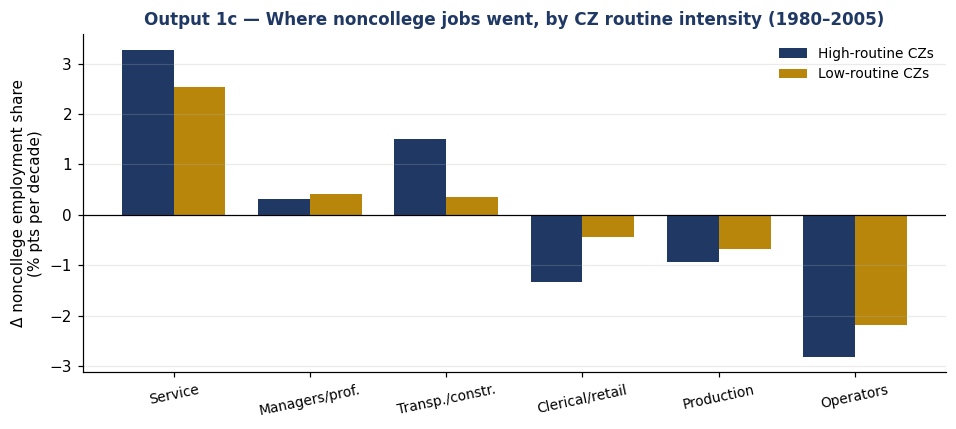

Saved outputs/output1c_occgroups.png


In [5]:
# --- Output 1c: where noncollege jobs went, high- vs low-routine CZs ---
# "High-routine" = CZ above the population-weighted grand mean of RSH_1980 (Autor & Dorn split)
base = panel[panel[["t1", "t2", "t3"]].sum(axis=1) == 1].dropna(
    subset=["l_sh_routine33a", "timepwt48"]).copy()
base["grp"] = np.where(base.l_sh_routine33a >= rsh_mean, "High routine", "Low routine")

occ = {"d_shocc1_service_nc": "Service", "d_shocc1_mgmtproftech_nc": "Managers/prof.",
       "d_shocc1_transconstr_nc": "Transp./constr.", "d_shocc1_clericretail_nc": "Clerical/retail",
       "d_shocc1_product_nc": "Production", "d_shocc1_operator_nc": "Operators"}
rows = []
for col, lab in occ.items():
    for g in ["High routine", "Low routine"]:
        s = base[base.grp == g].dropna(subset=[col])
        rows.append({"occ": lab, "grp": g, "val": 100 * wmean(s[col], s.timepwt48)})
piv = pd.DataFrame(rows).pivot(index="occ", columns="grp", values="val").reindex(list(occ.values()))

fig, ax = plt.subplots(figsize=(8.8, 4.0))
x = np.arange(len(piv)); w = 0.38
ax.bar(x - w/2, piv["High routine"], w, color=NAVY, label="High-routine CZs")
ax.bar(x + w/2, piv["Low routine"], w, color=GOLD, label="Low-routine CZs")
ax.axhline(0, color="k", lw=.8)
ax.set_xticks(x); ax.set_xticklabels(piv.index, rotation=12, fontsize=9)
ax.set_ylabel("Δ noncollege employment share\n(% pts per decade)")
ax.set_title("Output 1c — Where noncollege jobs went, by CZ routine intensity (1980–2005)",
             color=NAVY, fontsize=11)
ax.legend(fontsize=9, frameon=False); ax.grid(axis="y", alpha=.25)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "output1c_occgroups.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved", OUT / "output1c_occgroups.png")

Splitting CZs at the grand-mean routine share shows the mechanism on the *employment* side: in **high-routine CZs**, noncollege service employment rises **more**, while routine occupations (clerical/retail, production, operators) fall **more** than in low-routine CZs. Labour reallocates out of the automatable middle and into services exactly where there was more to automate.

## 3 · Analytical output — the horse race

We now estimate the cross-CZ relationship directly, stacking the three decadal differences 1980–2005 (722 CZs × 3 = 2,166 observations), weighting by start-of-period CZ population share and clustering standard errors on state. The dependent variable is the change in the **noncollege service-employment share** (`d_shocc1_service_nc`).

We run a staircase:
1. routine share only (Story A);
2. top-wage growth only (Story B);
3. **both** (the horse race);
4. both **+** college labour supply and offshorability;
5. a **2SLS** estimate that instruments the routine share with the **1950 industry-mix** prediction interacted with period dummies — predetermined three decades before the sample (Autor & Dorn, eq. 22) — plus the full Autor–Dorn control set and state/time fixed effects.


In [6]:
# build the stacked 1980-2005 sample
S = panel[panel[["t1", "t2", "t3"]].sum(axis=1) == 1].copy()
core = ["d_shocc1_service_nc", "l_sh_routine33a", "d_ln90wlsftfy",
        "d_avgls2080_edu_coll", "l_task_std_offshore", "timepwt48"]
S = S.dropna(subset=core)
# start-of-period 1950 instrument, interacted with period dummies (AD approach)
S["iv50"] = S.apply(lambda r: r[f"R33a_50_{int(r.yr)}"], axis=1)
S = S.dropna(subset=["iv50"])
for k in ("t1", "t2", "t3"):
    S[f"iv_{k}"] = S["iv50"] * S[k]
print("Horse-race sample:", len(S), "CZ × period observations")

Horse-race sample: 2166 CZ × period observations


In [7]:
def wls(cols):
    """Weighted OLS of service-employment change on `cols`, SEs clustered on state."""
    X = sm.add_constant(S[cols])
    return sm.WLS(S.d_shocc1_service_nc, X, weights=S.timepwt48).fit(
        cov_type="cluster", cov_kwds={"groups": S.statefip})

m1 = wls(["l_sh_routine33a"])
m2 = wls(["d_ln90wlsftfy"])
m3 = wls(["l_sh_routine33a", "d_ln90wlsftfy"])
m4 = wls(["l_sh_routine33a", "d_ln90wlsftfy", "d_avgls2080_edu_coll", "l_task_std_offshore"])

# Column 5: full 2SLS, AD controls + state & time FE, RSH instrumented by 1950 mix × period
AD_CTRL = ["l_relsup_highlow", "l_popfborn_shof_edulow", "l_shind_manuf",
           "l_unempl", "l_sh_empl_f", "l_shage_65up", "l_sh_minw"]
Siv = S.dropna(subset=AD_CTRL).copy()
TD = Siv[["t2", "t3"]].astype(float)
ST = pd.get_dummies(Siv.statefip, prefix="st", drop_first=True).astype(float)
exog = pd.concat([pd.Series(1.0, index=Siv.index, name="const"), Siv[AD_CTRL], TD, ST], axis=1)
iv = IV2SLS(dependent=Siv.d_shocc1_service_nc, exog=exog,
            endog=Siv[["l_sh_routine33a"]],
            instruments=Siv[["iv_t1", "iv_t2", "iv_t3"]],
            weights=Siv.timepwt48).fit(cov_type="clustered", clusters=Siv.statefip)
F1 = iv.first_stage.diagnostics.loc["l_sh_routine33a", "f.stat"]
print(f"2SLS routine-share coefficient = {iv.params['l_sh_routine33a']:.3f} "
      f"(se {iv.std_errors['l_sh_routine33a']:.3f}); first-stage F = {F1:.0f}")

2SLS routine-share coefficient = 0.149 (se 0.056); first-stage F = 174


In [8]:
# assemble a tidy results table
def star(b, se):
    z = abs(b / se)
    return "***" if z > 2.58 else "**" if z > 1.96 else "*" if z > 1.64 else ""

def cell_sm(m, k):
    return f"{m.params[k]:.3f}{star(m.params[k], m.bse[k])} ({m.bse[k]:.3f})" if k in m.params.index else "—"
def cell_iv(m, k):
    return f"{m.params[k]:.3f}{star(m.params[k], m.std_errors[k])} ({m.std_errors[k]:.3f})" if k in m.params.index else "—"

rowdefs = [("RSH (routine share)", "l_sh_routine33a"),
           ("Δ top wage (P90)", "d_ln90wlsftfy"),
           ("Δ college labour supply", "d_avgls2080_edu_coll"),
           ("Offshorability", "l_task_std_offshore")]
cols = ["(1) RSH", "(2) Demand", "(3) Horse race", "(4) + controls", "(5) 2SLS-IV"]
tab = pd.DataFrame(index=[r[0] for r in rowdefs], columns=cols)
for lab, k in rowdefs:
    tab.loc[lab, "(1) RSH"]        = cell_sm(m1, k)
    tab.loc[lab, "(2) Demand"]     = cell_sm(m2, k)
    tab.loc[lab, "(3) Horse race"] = cell_sm(m3, k)
    tab.loc[lab, "(4) + controls"] = cell_sm(m4, k)
    tab.loc[lab, "(5) 2SLS-IV"]    = cell_iv(iv, k)
tab.loc["State & time FE"] = ["No", "No", "No", "No", "Yes"]
tab.loc["Instrument (1950 mix)"] = ["No", "No", "No", "No", "Yes"]
tab.loc["N"] = [int(m1.nobs), int(m2.nobs), int(m3.nobs), int(m4.nobs), int(iv.nobs)]

tab.to_csv(OUT / "output2_horse_race.csv")
print("Dependent variable: Δ noncollege service-employment share (decadal)")
print("Weighted by CZ population; SEs clustered on state in parentheses. ***/**/* = 1/5/10%.\n")
display(tab)
print("\nSaved", OUT / "output2_horse_race.csv")

Dependent variable: Δ noncollege service-employment share (decadal)
Weighted by CZ population; SEs clustered on state in parentheses. ***/**/* = 1/5/10%.



,(1) RSH,(2) Demand,(3) Horse race,(4) + controls,(5) 2SLS-IV
RSH (routine share),0.124*** (0.029),—,0.096*** (0.027),0.173*** (0.032),0.149*** (0.056)
Δ top wage (P90),—,0.048*** (0.013),0.037*** (0.013),0.012 (0.014),—
Δ college labour supply,—,—,—,-0.110*** (0.029),—
Offshorability,—,—,—,-0.005 (0.003),—
State & time FE,No,No,No,No,Yes
Instrument (1950 mix),No,No,No,No,Yes
N,2166,2166,2166,2166,2166



Saved outputs/output2_horse_race.csv


**Reading the table.**

* The routine share (`RSH`) is positive and significant **alone** (col 1) and **survives** the horse race (col 3), the addition of demand-side controls (col 4), and full instrumentation (col 5, ≈ 0.15 — matching Autor & Dorn's headline 2SLS estimate). The first-stage F is far above conventional thresholds, so the instrument is strong.
* Top-wage growth is significant **alone** (col 2) but **attenuates sharply** once the routine share is present (col 3) and is indistinguishable from zero with controls (col 4).
* College labour-supply growth enters **negatively** (col 4) — the opposite of what a pure demand-pull/substitution story predicts.

So the demand-pull proxies do not survive conditioning, whereas the technological-push variable does. The horse race favours **Story A**.


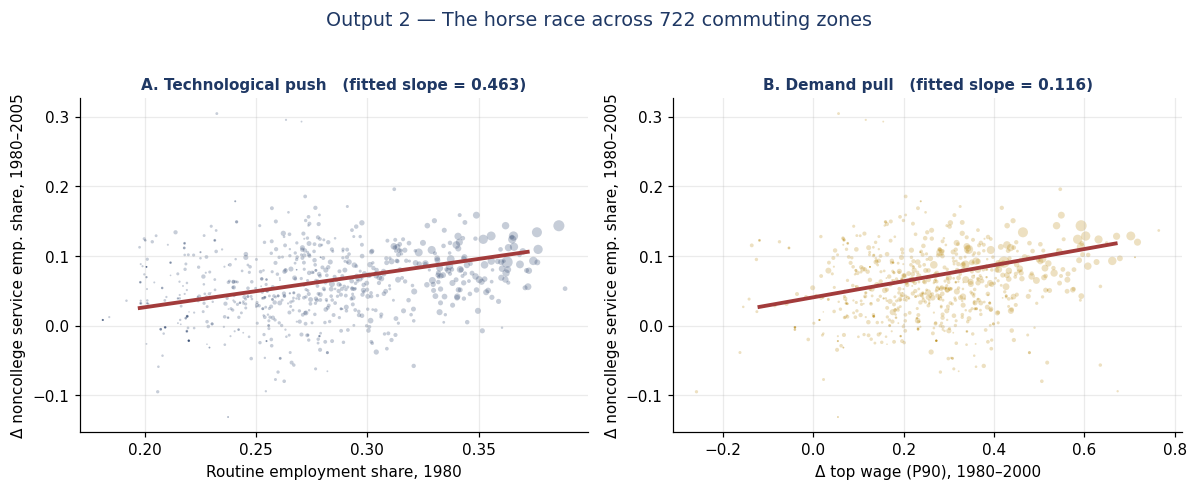

Saved outputs/output2_scatter.png


In [9]:
# --- Output 2: the horse-race scatter on the 722-CZ cross-section, 1980-2005 ---
# total 1980-2005 change per CZ = sum of the three decadal changes
def cz_cross(var):
    return panel.groupby("czone").apply(
        lambda g: g.loc[g.yr.isin([1980, 1990, 2000]), var].sum())

cs = pd.DataFrame({
    "dSVC":  cz_cross("d_shocc1_service_nc"),
    "topwg": cz_cross("d_ln90wlsftfy"),
})
cs["RSH80"] = panel[panel.yr == 1980].set_index("czone")["l_sh_routine33a"]
cs["w"]     = panel[panel.yr == 1980].set_index("czone")["timepwt48"]
cs = cs.dropna()

def wfit(x, y, w):
    b1, b0 = np.polyfit(x, y, 1, w=np.sqrt(w))
    return b0, b1

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
panels = [("RSH80", "Routine employment share, 1980", "A. Technological push", NAVY),
          ("topwg", "Δ top wage (P90), 1980–2000",    "B. Demand pull",        GOLD)]
for a, (xv, xlab, title, col) in zip(ax, panels):
    x, y, w = cs[xv].values, cs.dSVC.values, cs.w.values
    a.scatter(x, y, s=9 * np.sqrt(w / w.mean()), alpha=.25, color=col, edgecolors="none")
    b0, b1 = wfit(x, y, w)
    xs = np.linspace(np.percentile(x, 1), np.percentile(x, 99), 50)
    a.plot(xs, b0 + b1 * xs, color=RED, lw=2.5)
    a.set_title(f"{title}   (fitted slope = {b1:.3f})", color=NAVY, fontsize=10)
    a.set_xlabel(xlab); a.set_ylabel("Δ noncollege service emp. share, 1980–2005")
    a.grid(alpha=.25); a.spines[["top", "right"]].set_visible(False)
fig.suptitle("Output 2 — The horse race across 722 commuting zones", fontsize=12.5, color=NAVY)
fig.tight_layout(rect=[0, 0, 1, .95])
fig.savefig(OUT / "output2_scatter.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved", OUT / "output2_scatter.png")

Both raw slopes are positive, because the two mechanisms are **entangled** across space: routine-intensive CZs *also* enjoyed faster top-wage growth (the unconditional correlation is ≈ 0.29). That entanglement is precisely why a scatter alone cannot adjudicate, and why the regression — which holds one mechanism fixed while varying the other, and instruments the routine share with predetermined 1950 industry structure — is needed. Once that is done, only the technological-push channel survives.

## 4 · Conclusion

Placed in the same specification on the same 722 commuting zones, the **technological-push** measure (the 1980 routine employment share) robustly predicts the growth of noncollege service employment — alone, in the horse race, with demand-side controls, and under instrumentation (2SLS ≈ 0.15, matching Autor & Dorn). The **demand-pull** proxies are significant in isolation but do not survive conditioning, and college labour-supply growth even enters with the wrong sign. On this dataset, the data favour automation over rising local wealth as the dominant driver.

**Limitations.** Wages are nationally deflated, so cross-CZ comparisons are nominal; the routine index is fixed at 1980 task content; the panel ends in 2005; and the design is not built to recover a causal local multiplier à la Moretti (that would need a tradable-employment shift-share instrument) — so this is a *relative* adjudication, not a rejection of demand effects everywhere.

**Reproducibility.** Run top-to-bottom from a clean environment after `pip install -r requirements.txt`. All figures and the results table are written to `outputs/`.

*Acknowledgement of AI use.* We used a large-language-model assistant (Claude) to inspect the `.dta` files, sanity-check summary statistics and candidate specifications, and to refine prose and plotting code. All modelling choices and interpretations are our own, and we can explain every line of this notebook.
